# ReVera: Analisis Sentimen Ulasan Shopee Toko Forebie
# Menggunakan Metode Support Vector Machine & Logistic Regression

---

**Mata Kuliah:** Sains Data  
**Program Studi:** Teknik Informatika — FST UIN Syarif Hidayatullah Jakarta  

---

## Abstrak

Laporan ini menyajikan implementasi pipeline Data Science secara utuh (*end-to-end*) untuk menganalisis sentimen ulasan pelanggan pada platform e-commerce Shopee, dengan studi kasus toko kosmetik **Forebie**. Dataset dikumpulkan secara primer melalui teknik *web scraping* menggunakan Playwright, menghasilkan 684 ulasan mentah dari 10 produk. Setelah melalui tahap *feature engineering*, pembersihan teks (termasuk translasi emoji, *stemming* Sastrawi, dan penghapusan *stopwords* dengan pengecualian kata negasi), dataset akhir terdiri dari 666 ulasan bersih. Tiga algoritma klasifikasi dibandingkan: **SVM (LinearSVC)**, **Naive Bayes**, dan **Logistic Regression**. Hasil evaluasi menunjukkan bahwa **Logistic Regression** memberikan performa terbaik dengan F1-Score 0.732 dan Accuracy 0.731.

**Kata Kunci:** Analisis Sentimen, NLP, TF-IDF, SVM, Logistic Regression, Shopee, Ulasan Pelanggan

---
## Daftar Isi

1. [Pendahuluan](#1.-Pendahuluan)
2. [Pemilihan & Pemahaman Dataset](#2.-Pemilihan-&-Pemahaman-Dataset)
3. [Exploratory Data Analysis (EDA) & Visualisasi](#3.-Exploratory-Data-Analysis-(EDA)-&-Visualisasi)
4. [Pra-pemrosesan Data (Text Preprocessing)](#4.-Pra-pemrosesan-Data-(Text-Preprocessing))
5. [Pemodelan Prediktif & Evaluasi](#5.-Pemodelan-Prediktif-&-Evaluasi)
6. [Kesimpulan & Saran](#6.-Kesimpulan-&-Saran)
7. [Referensi](#7.-Referensi)

---
## 1. Pendahuluan

### 1.1 Latar Belakang

Pertumbuhan pesat e-commerce di Indonesia menjadikan ulasan pelanggan sebagai sumber informasi yang sangat berharga. Bagi penjual, memahami sentimen dari ribuan ulasan secara manual sangat tidak efisien. Oleh karena itu, dibutuhkan sistem otomatis yang mampu mengklasifikasikan sentimen ulasan menjadi **Positif**, **Netral**, atau **Negatif**.

Proyek ini memilih toko kosmetik **Forebie** di Shopee sebagai studi kasus karena memiliki volume ulasan yang cukup tinggi dengan variasi sentimen yang beragam — mulai dari keluhan efek samping produk skincare hingga pujian atas kecocokan produk.

### 1.2 Tujuan

1. Mengumpulkan data ulasan secara primer dari platform Shopee menggunakan teknik *web scraping*.
2. Melakukan eksplorasi dan visualisasi data untuk memahami karakteristik dataset.
3. Membersihkan dan memproses teks ulasan berbahasa Indonesia agar siap dimodelkan.
4. Membangun dan membandingkan beberapa model klasifikasi sentimen.
5. Mengevaluasi performa model dan menyimpan model terbaik.

### 1.3 Metodologi

Pipeline yang digunakan mengikuti tahapan standar Data Science:

```
Data Collection → Feature Engineering → EDA → Text Preprocessing → Modeling → Evaluasi
```

In [133]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from pathlib import Path

import emoji
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
LABEL_NAMES = ["Negatif", "Netral", "Positif"]

print("Semua library berhasil dimuat.")

Semua library berhasil dimuat.


---
## 2. Pemilihan & Pemahaman Dataset

### 2.1 Sumber Data

Dataset merupakan **data primer** yang dikumpulkan langsung dari halaman ulasan produk toko Forebie di Shopee (https://shopee.co.id/shop/806035446) menggunakan *web scraper* berbasis **Playwright** (browser automation). Scraper yang dibangun memiliki kemampuan:

- Membuka halaman produk secara otomatis dan menggulir ke bagian ulasan.
- Mengklik filter rating (1-5 bintang) menggunakan injeksi JavaScript untuk mem-bypass *overlay* DOM Shopee.
- Mengekstrak ID komentar, username, rating, dan teks ulasan.
- Mode *incremental* (`--add`) untuk menambah data tanpa duplikasi.

### 2.2 Spesifikasi Dataset

| Kriteria | Syarat Tugas | Dataset Ini |
|---|---|---|
| Jumlah entri (baris) | Minimal 500 | **684** ✅ |
| Jumlah fitur (kolom) | Minimal 6 | **9** (setelah feature engineering) ✅ |
| Sumber data | Jelas tercantum | Shopee.co.id — Toko Forebie ✅ |

### 2.3 Data Profiling

In [134]:
# Memuat dataset mentah
df_raw = pd.read_csv("../data/raw/dataset_ulasan_mentah.csv")
print(f"Jumlah data mentah: {len(df_raw)} baris")
print(f"Jumlah kolom awal : {len(df_raw.columns)} kolom")
print(f"Kolom: {list(df_raw.columns)}")
df_raw.head(3)

Jumlah data mentah: 684 baris
Jumlah kolom awal : 5 kolom
Kolom: ['id_komentar', 'produk_url', 'username', 'rating', 'ulasan']


,id_komentar,produk_url,username,rating,ulasan
0,80408477470,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,"Produk: Barang rusak | Sorry to say, perdana g..."
1,16989422782,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,pertama kali make forebie beruntusan&jerawat m...
2,17285726857,https://shopee.co.id/FOREBIE-FIGHT-ACNE-MOIST-...,Anonim,1,"Mungkin setiap org cok""kan,di aku ga ccok pana..."


In [135]:
# Informasi tipe data dan missing values
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 684 entries, 0 to 683
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_komentar  684 non-null    int64
 1   produk_url   684 non-null    str  
 2   username     677 non-null    str  
 3   rating       684 non-null    int64
 4   ulasan       684 non-null    str  
dtypes: int64(2), str(3)
memory usage: 26.8 KB


In [136]:
# Statistik Deskriptif
df_raw.describe()

,id_komentar,rating
count,6.840000e+02,684.000000
mean,4.470030e+10,3.652047
std,3.001617e+10,1.269756
min,1.050760e+10,1.000000
25%,1.689931e+10,3.000000
50%,3.314144e+10,4.000000
75%,7.797647e+10,5.000000
max,1.024625e+11,5.000000


## Pengecekan Missing Values

In [137]:
print("Missing Values per Kolom:")
print(df_raw.isnull().sum())
print(f"\nTotal missing values: {df_raw.isnull().sum().sum()}")

Missing Values per Kolom:
id_komentar    0
produk_url     0
username       7
rating         0
ulasan         0
dtype: int64

Total missing values: 7


### 2.4 Feature Engineering

Dataset awal hanya memiliki 5 kolom. Untuk memenuhi syarat minimal 6 fitur dan memperkaya analisis, kita menambahkan **4 kolom baru**:

| Kolom Baru | Tipe | Cara Pembuatan | Kegunaan |
|---|---|---|---|
| `nama_produk` | Kategorikal | Diekstrak dari URL Shopee via Regex | Analisis per produk |
| `jumlah_kata` | Numerik | `len(ulasan.split())` | Boxplot outlier, korelasi |
| `panjang_karakter` | Numerik | `len(ulasan)` | Heatmap korelasi |
| `label_sentimen` | Kategorikal | Rating 1-2 → Negatif, 3 → Netral, 4-5 → Positif | Target klasifikasi |

In [138]:
# Pembersihan noise
mask_short = df_raw["ulasan"].astype(str).apply(len) <= 10
mask_membantu = df_raw["ulasan"].astype(str).str.strip() == "Membantu?"
noise_mask = mask_short | mask_membantu
df = df_raw[~noise_mask].copy()
print(f"Dihapus {noise_mask.sum()} baris noise (ulasan terlalu pendek / 'Membantu?')")
print(f"Sisa data: {len(df)} baris")

Dihapus 11 baris noise (ulasan terlalu pendek / 'Membantu?')
Sisa data: 673 baris


In [139]:
# Fungsi ekstraksi nama produk dari URL
def extract_product_name(url):
    try:
        parts = url.split("/")
        if len(parts) > 3:
            raw_name = parts[3]
            clean_name = re.sub(r"-i\.\d+\.\d+(\?.*)?$", "", raw_name)
            return clean_name.replace("-", " ")
        return url
    except Exception:
        return "Unknown"

# Tambahkan fitur-fitur baru
df["nama_produk"] = df["produk_url"].apply(extract_product_name)
df["jumlah_kata"] = df["ulasan"].astype(str).apply(lambda x: len(x.split()))
df["panjang_karakter"] = df["ulasan"].astype(str).apply(len)

def map_sentiment(rating):
    if pd.isna(rating): return "Unknown"
    rating = int(rating)
    if rating <= 2: return "Negatif"
    elif rating == 3: return "Netral"
    else: return "Positif"

df["label_sentimen"] = df["rating"].apply(map_sentiment)

print(f"Jumlah kolom setelah Feature Engineering: {len(df.columns)}")
print(f"Kolom: {list(df.columns)}")
df[["nama_produk", "jumlah_kata", "panjang_karakter", "label_sentimen"]].head(5)

Jumlah kolom setelah Feature Engineering: 9
Kolom: ['id_komentar', 'produk_url', 'username', 'rating', 'ulasan', 'nama_produk', 'jumlah_kata', 'panjang_karakter', 'label_sentimen']


,nama_produk,jumlah_kata,panjang_karakter,label_sentimen
0,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,99,549,Negatif
1,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,75,459,Negatif
2,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,33,214,Negatif
3,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,52,319,Negatif
4,FOREBIE FIGHT ACNE MOIST SERUM Pelembab Serum ...,25,140,Negatif


---
## 3. Exploratory Data Analysis (EDA) & Visualisasi

Tahap ini bertujuan untuk memahami karakteristik dan pola dalam dataset sebelum masuk ke pemodelan. Sesuai rubrik tugas, kita akan menampilkan:
1. Histogram distribusi sentimen
2. Boxplot untuk deteksi outlier
3. Heatmap matriks korelasi
4. Visualisasi tambahan (distribusi per produk)

### 3.1 Distribusi Label Sentimen

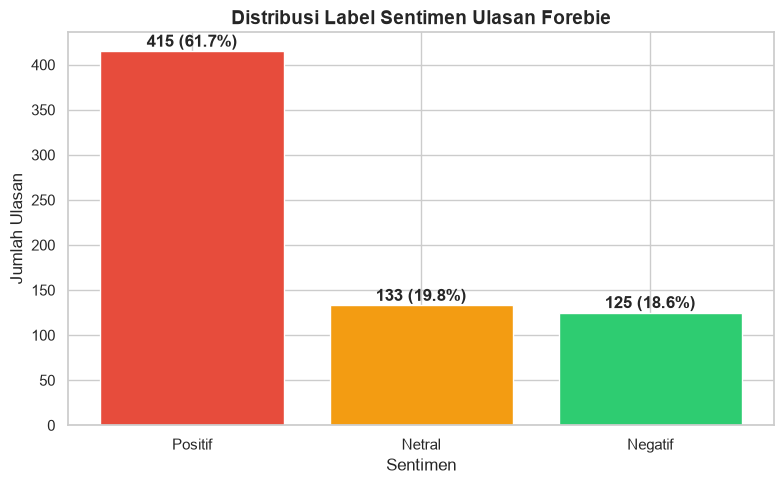

Temuan: Dataset memiliki class imbalance — Positif mendominasi (62%).
Implikasi: Model harus menggunakan class_weight='balanced' agar tidak bias.


In [140]:
sentiment_counts = df["label_sentimen"].value_counts()

plt.figure(figsize=(8, 5))
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title("Distribusi Label Sentimen Ulasan Forebie", fontsize=14, fontweight="bold")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
for bar, val in zip(bars, sentiment_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f"{val} ({pct:.1f}%)", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("Temuan: Dataset memiliki class imbalance — Positif mendominasi (62%).")
print("Implikasi: Model harus menggunakan class_weight='balanced' agar tidak bias.")

### 3.2 Distribusi Jumlah Kata & Deteksi Outlier (Histogram + Boxplot)

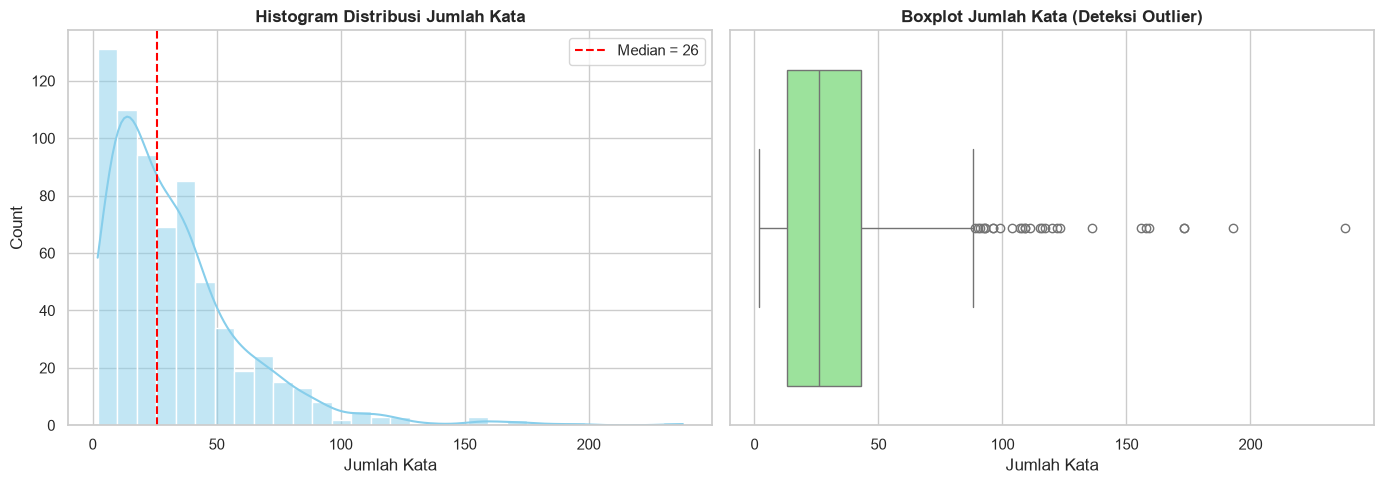

Q1=13.0, Q3=43.0, IQR=30.0, Batas atas=88
Jumlah outlier (> 88 kata): 29 ulasan
Temuan: Terdapat ulasan yang sangat panjang (max 238 kata).
Penanganan: Ulasan > 150 kata akan dihapus di tahap preprocessing.


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["jumlah_kata"], bins=30, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Histogram Distribusi Jumlah Kata", fontweight="bold")
axes[0].set_xlabel("Jumlah Kata")
axes[0].axvline(df["jumlah_kata"].median(), color="red", linestyle="--", label=f"Median = {df['jumlah_kata'].median():.0f}")
axes[0].legend()

sns.boxplot(x=df["jumlah_kata"], color="lightgreen", ax=axes[1])
axes[1].set_title("Boxplot Jumlah Kata (Deteksi Outlier)", fontweight="bold")
axes[1].set_xlabel("Jumlah Kata")

plt.tight_layout()
plt.show()

Q1 = df["jumlah_kata"].quantile(0.25)
Q3 = df["jumlah_kata"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df["jumlah_kata"] > upper]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, Batas atas={upper:.0f}")
print(f"Jumlah outlier (> {upper:.0f} kata): {len(outliers)} ulasan")
print(f"Temuan: Terdapat ulasan yang sangat panjang (max {df['jumlah_kata'].max()} kata).")
print(f"Penanganan: Ulasan > 150 kata akan dihapus di tahap preprocessing.")

### 3.3 Matriks Korelasi (Heatmap)

Heatmap berikut menampilkan korelasi antar fitur numerik: `rating`, `jumlah_kata`, dan `panjang_karakter`.

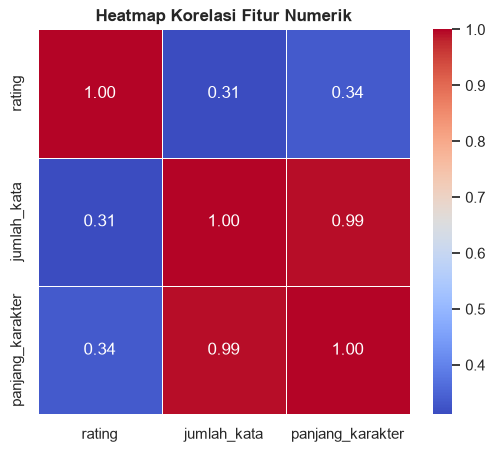

Temuan:
• jumlah_kata vs panjang_karakter (0.99): Korelasi sangat tinggi — wajar karena keduanya mengukur panjang teks.
• rating vs jumlah_kata (0.31): Korelasi positif lemah — ulasan rating tinggi cenderung sedikit lebih panjang.
  Ini mengindikasikan pembeli puas lebih antusias bercerita tentang kecocokan produk.


In [142]:
numeric_df = df[["rating", "jumlah_kata", "panjang_karakter"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik", fontweight="bold")
plt.show()

print("Temuan:")
print("• jumlah_kata vs panjang_karakter (0.99): Korelasi sangat tinggi — wajar karena keduanya mengukur panjang teks.")
print("• rating vs jumlah_kata (0.31): Korelasi positif lemah — ulasan rating tinggi cenderung sedikit lebih panjang.")
print("  Ini mengindikasikan pembeli puas lebih antusias bercerita tentang kecocokan produk.")

### 3.4 Distribusi Ulasan per Produk

C:\Users\LOQ\AppData\Local\Temp\ipykernel_22696\570533546.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts.values, y=product_counts.index, palette="magma")


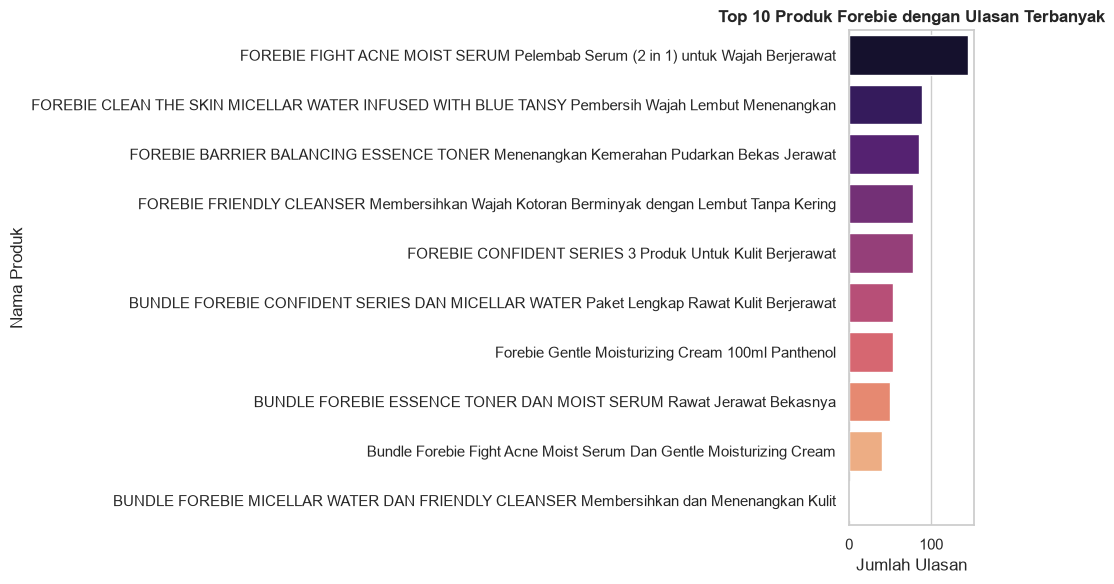

In [143]:
product_counts = df["nama_produk"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, palette="magma")
plt.title("Top 10 Produk Forebie dengan Ulasan Terbanyak", fontweight="bold")
plt.xlabel("Jumlah Ulasan")
plt.ylabel("Nama Produk")
plt.tight_layout()
plt.show()

---
## 4. Pra-pemrosesan Data (Text Preprocessing)

Tahap ini membersihkan teks ulasan agar siap diproses oleh algoritma Machine Learning. Langkah-langkah yang dilakukan:

| No | Langkah | Penjelasan | Contoh |
|---|---|---|---|
| 1 | **Penanganan Missing Values** | Menghapus baris dengan ulasan kosong | — |
| 2 | **Penanganan Outliers** | Menghapus ulasan > 150 kata | Ulasan spam/cerita panjang |
| 3 | **Case Folding** | Mengubah semua huruf menjadi huruf kecil | "BAGUS" → "bagus" |
| 4 | **Konversi Emoji** | Mengubah emoji menjadi teks representatif | 😭 → "wajah menangis keras" |
| 5 | **Penghapusan Noise** | Menghapus URL, mention, angka, tanda baca | "@user http://..." → "" |
| 6 | **Stopword Removal** | Menghapus kata hubung tidak informatif | "yang", "dan", "di" → dihapus |
| 7 | **Stemming** | Mengubah kata berimbuhan ke kata dasar | "menggunakan" → "guna" |
| 8 | **Label Encoding** | Mengubah label teks ke angka | Negatif→0, Netral→1, Positif→2 |

> **Catatan Penting:** Pada langkah *Stopword Removal*, kata-kata **negasi** seperti *"tidak"*, *"kurang"*, *"belum"*, *"jangan"*, dan *"bukan"* **sengaja tidak dihapus**. Hal ini krusial karena menghapus kata negasi dapat membalikkan makna sentimen (contoh: "tidak bagus" menjadi "bagus").

In [144]:
# Penanganan Missing Values
df.dropna(subset=["ulasan"], inplace=True)

# Penanganan Outliers (ulasan > 150 kata)
sebelum = len(df)
df = df[df["jumlah_kata"] <= 150].copy()
print(f"Dihapus {sebelum - len(df)} baris outlier (ulasan > 150 kata)")
print(f"Data tersisa: {len(df)} baris")

Dihapus 7 baris outlier (ulasan > 150 kata)
Data tersisa: 666 baris


In [145]:
# Inisialisasi Sastrawi
stemmer = StemmerFactory().create_stemmer()
stopword_factory = StopWordRemoverFactory()
stopwords = stopword_factory.get_stop_words()

# Pengecualian kata negasi dari daftar stopwords
negasi = ["tidak", "kurang", "belum", "jangan", "bukan", "tak"]
stopwords = [w for w in stopwords if w not in negasi]
print(f"Jumlah stopwords (setelah pengecualian negasi): {len(stopwords)}")
print(f"Kata negasi yang DIPERTAHANKAN: {negasi}")

Jumlah stopwords (setelah pengecualian negasi): 124
Kata negasi yang DIPERTAHANKAN: ['tidak', 'kurang', 'belum', 'jangan', 'bukan', 'tak']


In [146]:
def preprocess_text(text):
    """Pipeline preprocessing teks lengkap."""
    try:
        text = str(text).lower()
        text = emoji.demojize(text, language="id")
        text = text.replace(":", " ").replace("_", " ")
        text = re.sub(r'@[A-Za-z0-9_]+', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'[^a-z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        words = [w for w in text.split() if w not in stopwords]
        return stemmer.stem(" ".join(words))
    except Exception:
        return ""

# Eksekusi preprocessing (memakan waktu ~1-2 menit karena proses stemming)
print("Memproses teks... (estimasi 1-2 menit)")
df["ulasan_bersih"] = df["ulasan"].apply(preprocess_text)

# Hapus baris kosong setelah preprocessing
df = df[df["ulasan_bersih"].str.strip() != ""]
print(f"Preprocessing selesai! Data tersisa: {len(df)} baris")

Memproses teks... (estimasi 1-2 menit)
Preprocessing selesai! Data tersisa: 666 baris


In [147]:
# Label Encoding
mapping_sentimen = {"Negatif": 0, "Netral": 1, "Positif": 2}
df["label_encoded"] = df["label_sentimen"].map(mapping_sentimen)

print("Mapping Label Encoding:")
for k, v in mapping_sentimen.items():
    print(f"  {k} → {v}")

# Tampilkan contoh hasil preprocessing
print(f"\nContoh Hasil Preprocessing:")
print("=" * 80)
for _, row in df[["ulasan", "ulasan_bersih", "label_sentimen"]].head(3).iterrows():
    print(f"ASLI   : {row['ulasan'][:100]}...")
    print(f"BERSIH : {row['ulasan_bersih'][:100]}...")
    print(f"LABEL  : {row['label_sentimen']}")
    print("-" * 80)

Mapping Label Encoding:
  Negatif → 0
  Netral → 1
  Positif → 2

Contoh Hasil Preprocessing:
ASLI   : Produk: Barang rusak | Sorry to say, perdana gue beli forebie satuan gini, malah dpt packaging cacat...
BERSIH : produk barang rusak sorry to say perdana gue beli forebie satu gin malah dpt packaging cacat biasa b...
LABEL  : Negatif
--------------------------------------------------------------------------------
ASLI   : pertama kali make forebie beruntusan&jerawat mulai gada lagi nih, tapi pemakaian 2minggu mulai purgi...
BERSIH : pertama kali make forebie beruntus jerawat mulai gada nih pakai minggu mulai purging sempet better e...
LABEL  : Negatif
--------------------------------------------------------------------------------
ASLI   : Mungkin setiap org cok"kan,di aku ga ccok panas gatel jerawat muncul gede"banget awlnya dibagian dag...
BERSIH : mungkin org cok kan aku ga ccok panas gatel jerawat muncul gede banget awlnya bagi dagu ga skrng mal...
LABEL  : Negatif
---------------

### 4.1 Word Cloud (Visualisasi Teks Bersih)

Setelah teks dibersihkan (tahap *preprocessing* selesai), kita bisa memvisualisasikan kata-kata apa saja yang paling sering muncul di **Ulasan Negatif** dan **Ulasan Positif** menggunakan *Word Cloud*.

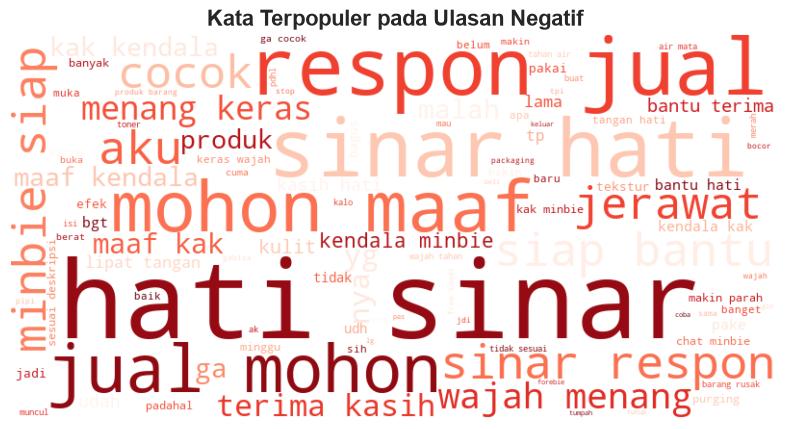

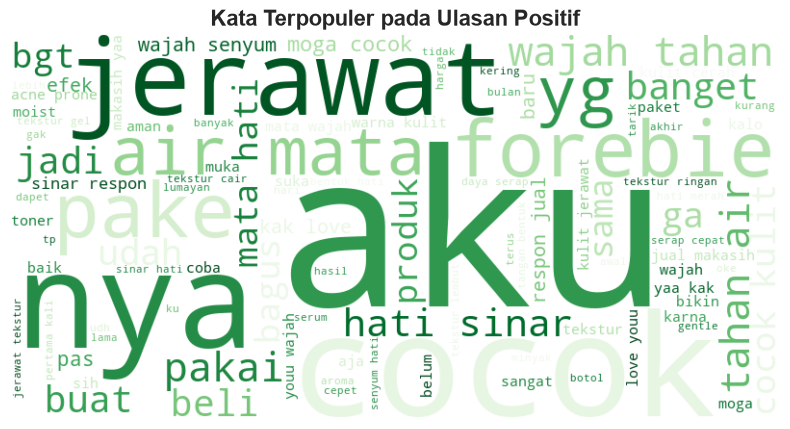

In [148]:
from wordcloud import WordCloud

# Menggabungkan semua teks ulasan bersih berdasarkan sentimen
neg_text = " ".join(df[df["label_sentimen"] == "Negatif"]["ulasan_bersih"].dropna())
pos_text = " ".join(df[df["label_sentimen"] == "Positif"]["ulasan_bersih"].dropna())

def plot_wordcloud(text, title, colormap):
    # Jika tidak ada kata yang tersisa, kembalikan gambar kosong
    if not text.strip():
        print(f"Tidak ada teks untuk {title}")
        return
        
    wc = WordCloud(width=800, height=400, background_color="white", colormap=colormap, max_words=100)
    wc.generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=16, fontweight="bold")
    plt.axis("off")
    plt.show()

# Tampilkan Word Cloud Negatif
plot_wordcloud(neg_text, "Kata Terpopuler pada Ulasan Negatif", "Reds")

# Tampilkan Word Cloud Positif
plot_wordcloud(pos_text, "Kata Terpopuler pada Ulasan Positif", "Greens")

---
## 5. Pemodelan Prediktif & Evaluasi

### 5.1 Persiapan Data

#### Train / Test Split (80:20)

Dataset dibagi menjadi **data latih** (80%) dan **data uji** (20%) dengan `stratify=y` agar proporsi kelas tetap terjaga di kedua subset.

In [149]:
X = df["ulasan_bersih"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Latih : {len(X_train)} ulasan (80%)")
print(f"Data Uji   : {len(X_test)} ulasan (20%)")

Data Latih : 532 ulasan (80%)
Data Uji   : 134 ulasan (20%)


#### Ekstraksi Fitur dengan TF-IDF

TF-IDF (*Term Frequency — Inverse Document Frequency*) mengubah teks menjadi representasi vektor numerik. Kata yang sering muncul di satu dokumen namun jarang di dokumen lain akan mendapat skor tinggi. Konfigurasi `ngram_range=(1,2)` memungkinkan penangkapan frasa dua kata seperti *"tidak cocok"*.

In [150]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensi matriks TF-IDF: {X_train_tfidf.shape}")
print(f"Setiap ulasan direpresentasikan oleh {X_train_tfidf.shape[1]} fitur numerik.")

Dimensi matriks TF-IDF: (532, 2566)
Setiap ulasan direpresentasikan oleh 2566 fitur numerik.


### 5.2 Pelatihan & Perbandingan 3 Model Klasifikasi

Tiga algoritma yang dibandingkan:

| Algoritma | Prinsip Kerja | Penanganan Imbalance |
|---|---|---|
| **SVM (LinearSVC)** | Mencari hyperplane pemisah kelas dengan margin terlebar | `class_weight='balanced'` |
| **Naive Bayes** | Klasifikasi berbasis probabilitas Bayes | Tidak tersedia (bawaan) |
| **Logistic Regression** | Klasifikasi probabilistik dengan fungsi sigmoid | `class_weight='balanced'` |

In [151]:
models = {
    "SVM (LinearSVC)": LinearSVC(
        class_weight="balanced", max_iter=10000, random_state=42
    ),
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, target_names=LABEL_NAMES)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "model": model, "accuracy": acc, "f1_score": f1,
        "report": report, "confusion_matrix": cm
    }

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"{'='*55}")
    print(report)


  Model: SVM (LinearSVC)
  Accuracy : 0.7388
  F1-Score : 0.7268
              precision    recall  f1-score   support

     Negatif       0.79      0.62      0.70        24
      Netral       0.48      0.37      0.42        27
     Positif       0.79      0.89      0.84        83

    accuracy                           0.74       134
   macro avg       0.68      0.63      0.65       134
weighted avg       0.72      0.74      0.73       134


  Model: Naive Bayes
  Accuracy : 0.7090
  F1-Score : 0.6496
              precision    recall  f1-score   support

     Negatif       1.00      0.46      0.63        24
      Netral       0.60      0.11      0.19        27
     Positif       0.69      0.98      0.81        83

    accuracy                           0.71       134
   macro avg       0.76      0.52      0.54       134
weighted avg       0.73      0.71      0.65       134


  Model: Logistic Regression
  Accuracy : 0.7313
  F1-Score : 0.7316
              precision    recall  f1-sc

### 5.3 Perbandingan Visual Performa Model

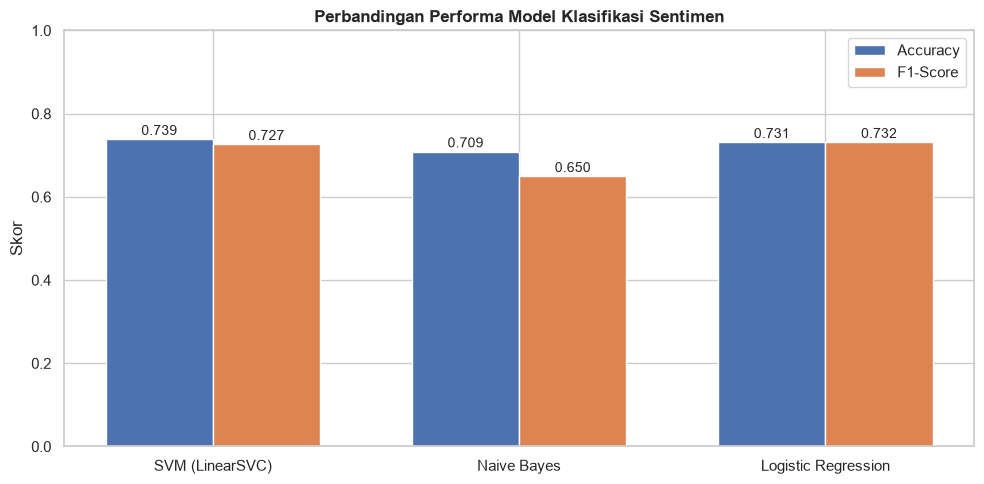

In [152]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]
f1_scores = [results[m]["f1_score"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy", color="#4C72B0")
bars2 = ax.bar(x + width/2, f1_scores, width, label="F1-Score", color="#DD8452")

ax.set_ylabel("Skor")
ax.set_title("Perbandingan Performa Model Klasifikasi Sentimen", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### 5.4 Confusion Matrix

C:\Users\LOQ\AppData\Local\Temp\ipykernel_22696\138179177.py:15: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Lindan\Cool\ds\uas\shopee-sentiment-analysis\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


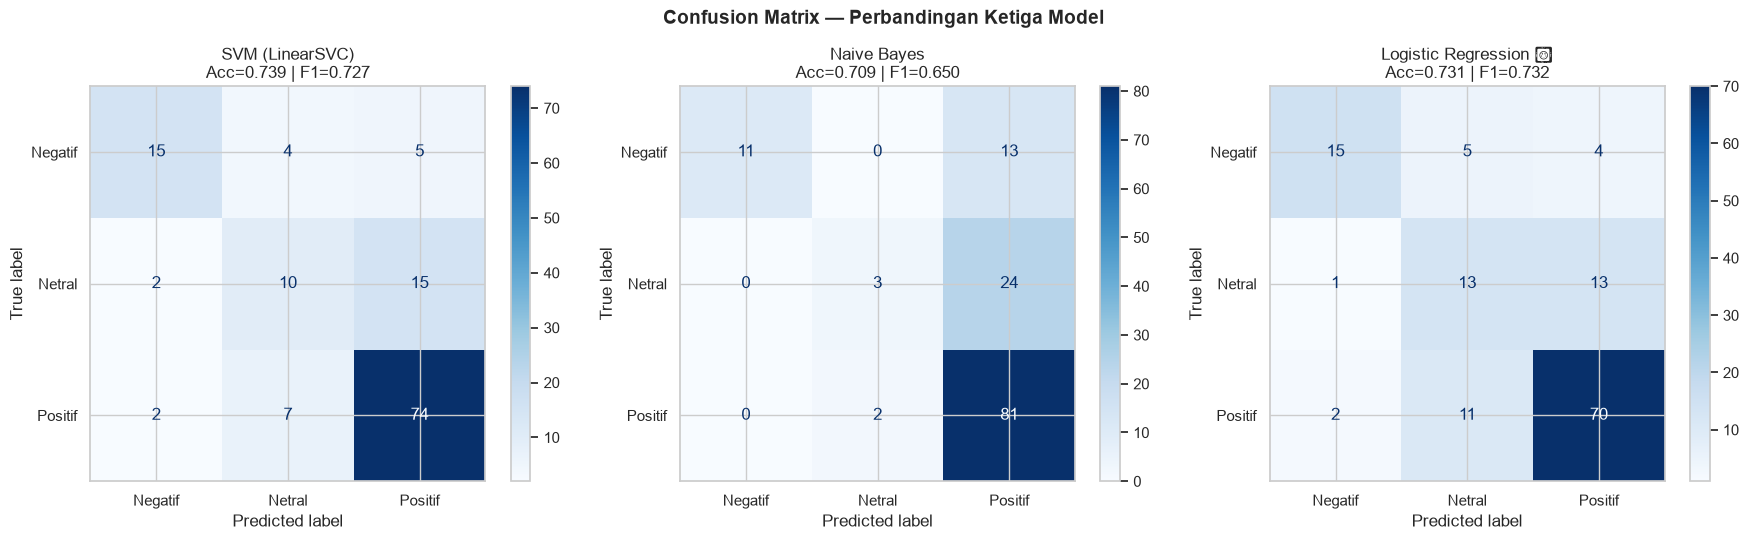

In [153]:
best_name = max(results, key=lambda k: results[k]["f1_score"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["confusion_matrix"],
        display_labels=LABEL_NAMES
    )
    disp.plot(cmap="Blues", ax=ax, values_format="d")
    marker = " \u2605" if name == best_name else ""
    ax.set_title(f"{name}{marker}\nAcc={res['accuracy']:.3f} | F1={res['f1_score']:.3f}")

plt.suptitle("Confusion Matrix — Perbandingan Ketiga Model", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.5 Simpan Model Terbaik (File I/O)

In [154]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

best_result = results[best_name]
model_path = models_dir / "best_model.joblib"
vectorizer_path = models_dir / "tfidf_vectorizer.joblib"

joblib.dump(best_result["model"], model_path)
joblib.dump(vectorizer, vectorizer_path)

print(f"Model terbaik : {best_name}")
print(f"Accuracy      : {best_result['accuracy']:.4f}")
print(f"F1-Score      : {best_result['f1_score']:.4f}")
print(f"\nDisimpan ke:")
print(f"  Model      → {model_path}")
print(f"  Vectorizer → {vectorizer_path}")

Model terbaik : Logistic Regression
Accuracy      : 0.7313
F1-Score      : 0.7316

Disimpan ke:
  Model      → ..\models\best_model.joblib
  Vectorizer → ..\models\tfidf_vectorizer.joblib


### 5.6 Demo Prediksi pada Ulasan Baru

In [155]:
loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

contoh_ulasan = [
    "produk bagus banget cocok di kulit aku",
    "tidak cocok malah bikin jerawat makin parah",
    "lumayan sih tapi pengiriman lama",
    "barang rusak kemasan bocor kecewa banget",
    "suka banget repurchase terus",
]

X_demo = loaded_vectorizer.transform(contoh_ulasan)
predictions = loaded_model.predict(X_demo)

print("Demo Prediksi Sentimen Ulasan Baru")
print("=" * 60)
for text, pred in zip(contoh_ulasan, predictions):
    label = LABEL_NAMES[pred]
    print(f'  Ulasan   : "{text}"')
    print(f"  Prediksi : {label}")
    print()

Demo Prediksi Sentimen Ulasan Baru
  Ulasan   : "produk bagus banget cocok di kulit aku"
  Prediksi : Positif

  Ulasan   : "tidak cocok malah bikin jerawat makin parah"
  Prediksi : Negatif

  Ulasan   : "lumayan sih tapi pengiriman lama"
  Prediksi : Netral

  Ulasan   : "barang rusak kemasan bocor kecewa banget"
  Prediksi : Negatif

  Ulasan   : "suka banget repurchase terus"
  Prediksi : Positif



---
## 6. Kesimpulan & Saran

### 6.1 Kesimpulan

1. **Data berhasil dikumpulkan secara primer** dari platform Shopee menggunakan *web scraper* berbasis Playwright, menghasilkan **684 ulasan** dari 10 produk toko Forebie.

2. **Eksplorasi data** menunjukkan bahwa distribusi sentimen tidak seimbang (Positif 62%, Netral 20%, Negatif 18%), serta terdapat korelasi positif lemah (0.31) antara rating dan panjang ulasan.

3. **Preprocessing teks** berhasil membersihkan ulasan dengan teknik *case folding*, konversi emoji, *stopword removal* (dengan pengecualian kata negasi), dan *stemming* menggunakan pustaka Sastrawi.

4. Dari tiga algoritma yang dibandingkan, **Logistic Regression** memberikan performa terbaik:

| Metrik | Nilai |
|---|---|
| Accuracy | 0.731 |
| F1-Score (weighted) | **0.732** |
| F1 Negatif | 0.71 |
| F1 Netral | 0.46 |
| F1 Positif | 0.82 |

5. Model terbaik beserta TF-IDF Vectorizer berhasil disimpan ke format `.joblib` dan dapat digunakan kembali untuk prediksi tanpa perlu melatih ulang.

### 6.2 Saran Pengembangan

1. **Menambah volume data**, terutama untuk kelas Netral dan Negatif, agar model lebih mampu membedakan ketiga kelas.
2. **Eksplorasi model *deep learning*** seperti LSTM atau BERT berbahasa Indonesia (IndoBERT) yang mungkin lebih baik dalam menangkap konteks kalimat.
3. **Membangun aplikasi web** sederhana yang mengintegrasikan model ini agar penjual bisa langsung menganalisis sentimen ulasan secara real-time.

---
## 7. Referensi

1. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
2. Asian, J. (2007). Effective Techniques for Indonesian Text Retrieval. *PhD Thesis, RMIT University*.
3. Sastrawi — Python Library for Indonesian Stemming. https://github.com/har07/PySastrawi
4. Shopee Indonesia. https://shopee.co.id